In [8]:
import pandas as pd
from matplotlib import pyplot as plt
import cv2

### Import dataset

In [3]:
df = pd.read_csv("/home/furkan/projects/mebar-orthognatic/data/processed/manifest.csv")
print(len(df))
df.head()

90


,sample_id,batch,image_path,image_name,width,height,landmark_count,cvat_image_name,source_xml,source_csv,...,lower_lip_anterior_y,pogonion_x,pogonion_y,subnasale_x,subnasale_y,tvl_lla,tvl_pog,tvl_ula,upper_lip_anterior_x,upper_lip_anterior_y
0,sample_57b07f090d8e5a14,batch-1-imgs,data/raw/batch-1-imgs/Resim1.jpg.jpg,Resim1.jpg.jpg,3712,2475,4,Resim1.jpg,data/raw/annotations batch 1 .xml,data/raw/batch-1-TVL-labels.csv,...,1863.17,2719.99,2111.27,2615.53,1610.71,1.615,1.256,0.807,2676.46,1723.88
1,sample_4b2dffab20c94d55,batch-1-imgs,data/raw/batch-1-imgs/Resim10.png.png,Resim10.png.png,1280,720,4,Resim10.png,data/raw/annotations batch 1 .xml,data/raw/batch-1-TVL-labels.csv,...,410.60,818.60,484.21,807.80,358.67,0.493,0.613,0.120,802.73,385.89
2,sample_78a8f7933b885acd,batch-1-imgs,data/raw/batch-1-imgs/Resim11.png,Resim11.png,1280,720,4,Resim11.png,data/raw/annotations batch 1 .xml,data/raw/batch-1-TVL-labels.csv,...,514.22,874.59,573.10,897.40,434.40,0.088,-0.791,0.387,904.35,477.50
3,sample_8ebecfcc96a54a03,batch-1-imgs,data/raw/batch-1-imgs/Resim12.jpg.jpg,Resim12.jpg.jpg,1694,2162,4,Resim12.jpg,data/raw/annotations batch 1 .xml,data/raw/batch-1-TVL-labels.csv,...,1320.00,1528.32,1503.98,1539.91,1124.14,0.256,-0.106,0.000,1538.01,1243.91
4,sample_817a2a6f8e67c23c,batch-1-imgs,data/raw/batch-1-imgs/Resim13.jpg,Resim13.jpg,1675,2475,4,Resim13.jpg,data/raw/annotations batch 1 .xml,data/raw/batch-1-TVL-labels.csv,...,1608.32,1460.30,1756.30,1562.61,1325.39,0.119,-1.391,0.398,1588.73,1451.62


In [4]:
df.describe()

,width,height,landmark_count,lower_lip_anterior_x,lower_lip_anterior_y,pogonion_x,pogonion_y,subnasale_x,subnasale_y,tvl_lla,tvl_pog,tvl_ula,upper_lip_anterior_x,upper_lip_anterior_y
count,90.000000,90.000000,90.0,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,2984.877778,3106.522222,4.0,2280.404667,1980.071889,2217.527667,2211.162222,2257.384222,1728.868667,0.236844,-0.451344,0.213344,2280.135889,1856.409333
std,1688.746659,1684.068043,0.0,1124.142384,1048.126800,1101.515869,1148.924660,1115.235450,940.065918,0.447759,1.033647,0.194497,1126.838067,999.404937
min,642.000000,613.000000,4.0,459.490000,387.930000,450.140000,437.210000,438.290000,335.490000,-0.968000,-3.180000,-0.334000,448.300000,356.340000
25%,1679.750000,2469.000000,4.0,1464.250000,1427.977500,1400.730000,1598.937500,1480.362500,1242.100000,0.000000,-1.288500,0.082000,1482.585000,1352.957500
50%,2159.500000,2475.000000,4.0,1770.550000,1624.070000,1720.725000,1821.685000,1743.205000,1397.900000,0.231500,-0.203000,0.206500,1793.450000,1527.800000
75%,4160.000000,4160.000000,4.0,3414.635000,2655.752500,3232.905000,2949.702500,3391.997500,2365.937500,0.506000,0.384000,0.307000,3409.612500,2511.182500
max,6240.000000,6240.000000,4.0,4437.190000,4233.000000,4357.160000,4650.200000,4374.440000,3821.490000,1.615000,1.512000,0.807000,4429.950000,4039.570000


### Missing value and duplicate check

In [5]:
# missing value check
df.isnull().sum()

sample_id               0
batch                   0
image_path              0
image_name              0
width                   0
height                  0
landmark_count          0
cvat_image_name         0
source_xml              0
source_csv              0
lower_lip_anterior_x    0
lower_lip_anterior_y    0
pogonion_x              0
pogonion_y              0
subnasale_x             0
subnasale_y             0
tvl_lla                 0
tvl_pog                 0
tvl_ula                 0
upper_lip_anterior_x    0
upper_lip_anterior_y    0
dtype: int64

In [ ]:
# duplicate check
df.duplicated().unique()

array([False])

### Image size distribution

In [17]:
num_duplicate = df["height"].duplicated().sum()
print("number of duplicate height dimension size: ", num_duplicate)

number of duplicate height dimension size:  57


In [18]:
num_duplicate = df["width"].duplicated().sum()
print("number of duplicate width dimension size: ", num_duplicate)

number of duplicate width dimension size:  34


Text(0.5, 1.0, 'height histogram')

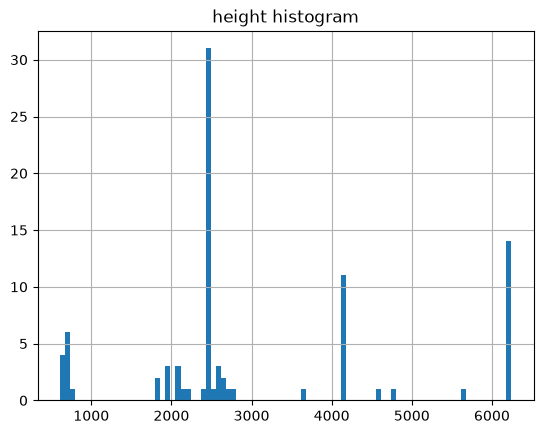

In [ ]:
ax = df["height"].hist(bins=len(df))
ax.set_title("height histogram")

Text(0.5, 1.0, 'width histogram')

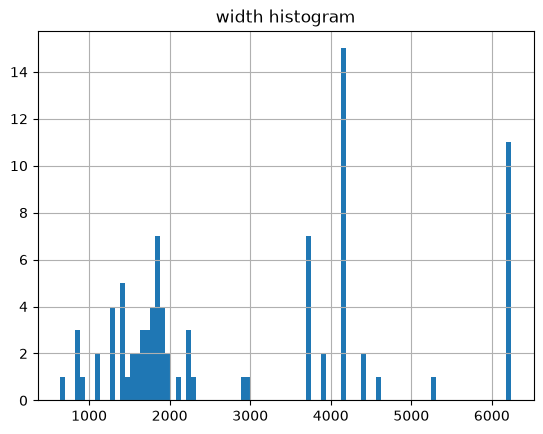

In [24]:
ax = df["width"].hist(bins=len(df))
ax.set_title("width histogram")

<Axes: xlabel='height', ylabel='width'>

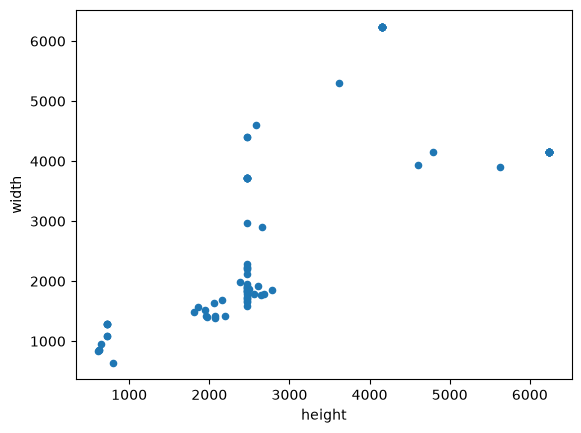

In [11]:
df.plot.scatter(x="height", y="width")

### Plotting keypoints on images

In [28]:
# configuration
root_folder = "/home/furkan/projects/mebar-orthognatic"

# unNone either one
save_file_name = None
save_folder_name = "/home/furkan/projects/mebar-orthognatic/data/labeled"

In [36]:
# define methods
def draw_keypoints(image, points) -> cv2.UMat:

    names = [
        "subnasale",
        "upper_lip_anterior",
        "lower_lip_anterior",
        "pogonion",
    ]

    for name, (x, y) in zip(names, points):

        cv2.putText(
            image,
            name,
            (int(x) + 5, int(y) - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 255),
            1,
            cv2.LINE_AA,
        )

    return image

points_columns = [
    "subnasale_x",
    "subnasale_y",
    "upper_lip_anterior_x",
    "upper_lip_anterior_y",
    "lower_lip_anterior_x",
    "lower_lip_anterior_y",
    "pogonion_x",
    "pogonion_y",
]


if save_folder_name:
    for index, row in df.iterrows():
        image = cv2.imread(f'{root_folder}/{row["image_path"]}')
        points = row[points_columns]
        points = [(points.iloc[2*i],points.iloc[2*i+1]) for i in range(4)]
        labeled_img = draw_keypoints(image, points)
        cv2.imwrite(f"{save_folder_name}/{row['image_name']}", labeled_img)

[ WARN:0@4113.993] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 36867 (0x9003) encountered
[ WARN:0@4113.993] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 37398 (0x9216) encountered


error: OpenCV(5.0.0) /io/opencv/modules/imgcodecs/src/loadsave.cpp:1174: error: (-215:Assertion failed) !_img.empty() in function 'imwrite'


[ERROR:0@4113.993] global loadsave.cpp:612 imread_ imread_('/home/furkan/projects/mebar-orthognatic/data/raw/batch-2-imgs/ABDULLAH SELMAN ARISOY.png'): can't read data: OpenCV(5.0.0) /io/opencv/modules/imgcodecs/src/loadsave.cpp:604: error: (-2:Unspecified error) in function 'bool cv::imread_(const String&, int, OutputArray, std::vector<int>*, OutputArrayOfArrays)'
> Internal imread issue:
>     'original_ptr == real_mat.data' must be 'true'

